### SIMPLE LINEAR REGRESSION
### Bengaluru House Price Prediction


### STEP 1: Import libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

### STEP 2: Load the dataset

In [2]:
df = pd.read_csv(r"E:\Data set\models\Bengaluru_House_Data.csv")
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [3]:
print("Dataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)


Dataset shape:
(13320, 9)

First 5 rows:
              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2      NaN       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4      NaN       1200   2.0      1.0   51.00  

Column names:
Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

Data types:
area_type        object
availabilit

### STEP 3: Check missing values

In [4]:
print("\nMissing values:")
df.isnull().sum()


Missing values:


area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

### STEP 4: Check basic statistics

In [5]:
print("\nStatistical summary:")
df.describe()


Statistical summary:


,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


### STEP 5: Select required columns

In [6]:
# We only need total_sqft and price
data = df[['total_sqft', 'price']].copy()

print("Selected data:")
print(data.head())

Selected data:
  total_sqft   price
0       1056   39.07
1       2600  120.00
2       1440   62.00
3       1521   95.00
4       1200   51.00


### STEP 6: Convert total_sqft into numeric format

**Some total_sqft values are like:**
- "1200"
- "1000-1200"
- "34.46Sq. Meter"


**Linear Regression requires numerical values.**

In [7]:

def convert_sqft_to_num(value):

    value = str(value).strip()

    # Handle values such as "1000-1200"
    if '-' in value:

        parts = value.split('-')

        try:
            low = float(parts[0])
            high = float(parts[1])

            # Take average of the range
            return (low + high) / 2

        except:
            return np.nan

    # Handle normal numeric values
    try:
        return float(value)

    except:
        return np.nan


data['total_sqft'] = data['total_sqft'].apply(convert_sqft_to_num)

### STEP 7: Check conversion

In [8]:
print("After converting total_sqft:")
print(data.head())

print("\n\n Missing values after conversion:")
print(data.isnull().sum())

After converting total_sqft:
   total_sqft   price
0      1056.0   39.07
1      2600.0  120.00
2      1440.0   62.00
3      1521.0   95.00
4      1200.0   51.00


 Missing values after conversion:
total_sqft    46
price          0
dtype: int64


### STEP 8: Remove rows with missing values

In [9]:
data = data.dropna()

print("Dataset shape after cleaning:")
print(data.shape)

Dataset shape after cleaning:
(13274, 2)


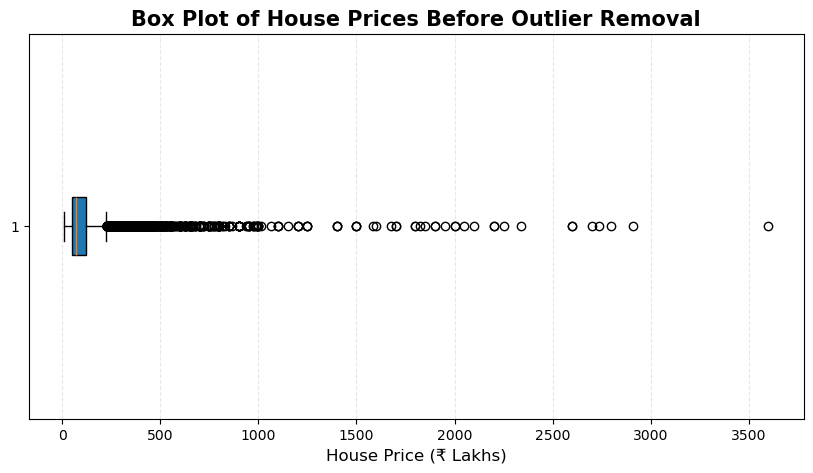

In [10]:
# BOX PLOT - BEFORE OUTLIER REMOVAL
# Price

plt.figure(figsize=(10, 5))

plt.boxplot(data["price"], vert=False, patch_artist=True) #price

plt.xlabel("House Price (₹ Lakhs)", fontsize=12)

plt.title("Box Plot of House Prices Before Outlier Removal", fontsize=15, fontweight="bold")

plt.grid(axis="x", linestyle="--", alpha=0.3)

# plt.tight_layout()

plt.show()

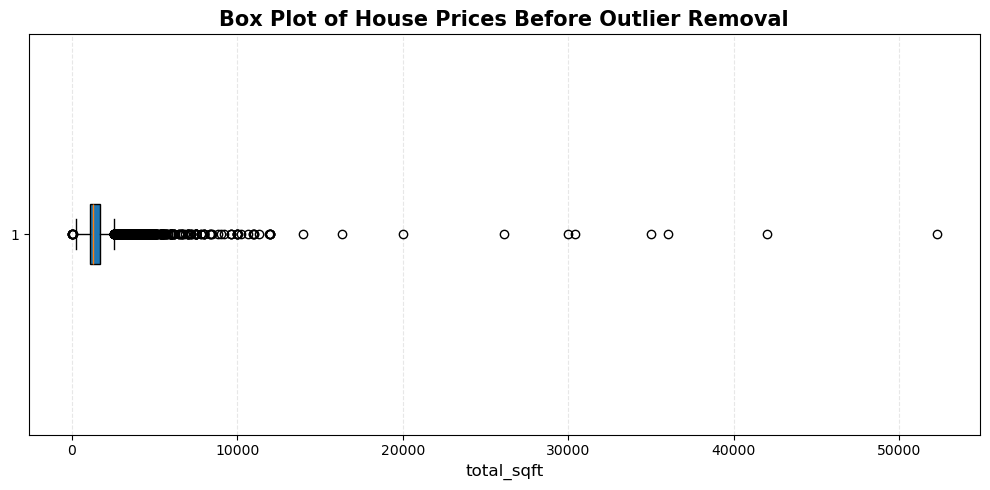

In [11]:
plt.figure(figsize=(10, 5))

plt.boxplot(data["total_sqft"], vert=False, patch_artist=True)

plt.xlabel("total_sqft", fontsize=12)

plt.title("Box Plot of House Prices Before Outlier Removal", fontsize=15, fontweight="bold")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

In [12]:
# IQR = Q3 - Q1

## Lower Bound = Q1 - 1.5 * IQR 
## Upper Bound = Q3 + 1.5 * IQR


def remove_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)

    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR

    upper_bound = Q3 + 1.5 * IQR

    print(f"\n{column} outlier boundaries:")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)

    filtered_data = data[(data[column] >= lower_bound) &
        (data[column] <= upper_bound)]

    return filtered_data


### STEP 7: Remove total_sqft outliers

In [13]:
data = remove_outliers_iqr(data,"total_sqft")

data.head()


total_sqft outlier boundaries:
Q1: 1100.0
Q3: 1680.0
IQR: 580.0
Lower Bound: 230.0
Upper Bound: 2550.0


,total_sqft,price
0,1056.0,39.07
2,1440.0,62.00
3,1521.0,95.00
4,1200.0,51.00
5,1170.0,38.00


### STEP 8: Remove Price outliers

In [14]:
data = remove_outliers_iqr(data,"price")

print("\nAfter price outlier removal:")
print(data.shape)


price outlier boundaries:
Q1: 48.0
Q3: 100.0
IQR: 52.0
Lower Bound: -30.0
Upper Bound: 178.0

After price outlier removal:
(11227, 2)


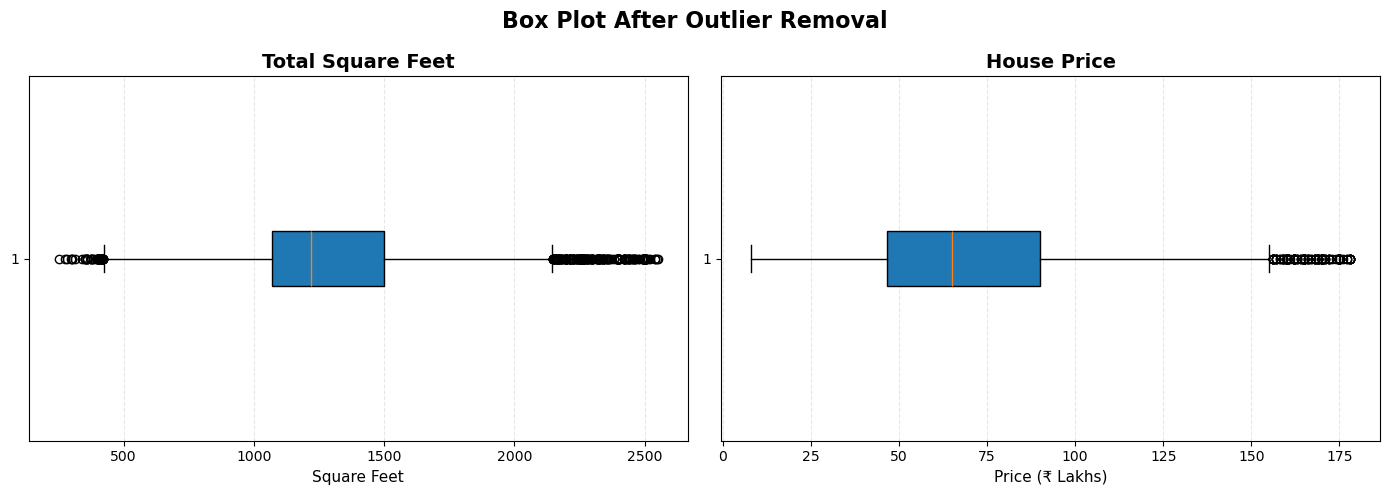

In [15]:
# BOX PLOTS FOR TOTAL SQFT AND PRICE

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total sqft
axes[0].boxplot(data["total_sqft"], vert=False, patch_artist=True)

axes[0].set_title("Total Square Feet", fontsize=14, fontweight="bold")

axes[0].set_xlabel("Square Feet", fontsize=11)

axes[0].grid(axis="x", linestyle="--", alpha=0.3)


# Price
axes[1].boxplot(data["price"], vert=False, patch_artist=True)

axes[1].set_title("House Price", fontsize=14, fontweight="bold")

axes[1].set_xlabel("Price (₹ Lakhs)", fontsize=11)

axes[1].grid(axis="x", linestyle="--", alpha=0.3)


plt.suptitle("Box Plot After Outlier Removal", fontsize=16, fontweight="bold")

plt.tight_layout()

plt.show()

### STEP 9: Visualize cleaned data

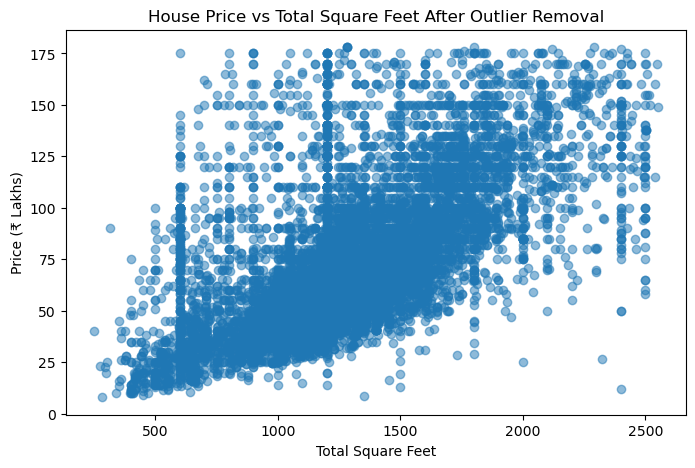

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(data["total_sqft"], data["price"], alpha=0.5)

plt.xlabel("Total Square Feet")
plt.ylabel("Price (₹ Lakhs)")
plt.title("House Price vs Total Square Feet After Outlier Removal")

plt.show()

### STEP 9: Define X and y

In [17]:
# X = independent/input variable
# y = dependent/target variable


X = data[['total_sqft']]
y = data['price']

In [18]:
print("X:")
print(X.head())

X:
   total_sqft
0      1056.0
2      1440.0
3      1521.0
4      1200.0
5      1170.0


In [19]:
print("y:")
print(y.head())

y:
0    39.07
2    62.00
3    95.00
4    51.00
5    38.00
Name: price, dtype: float64


### STEP 10: Visualize relationship between X and y

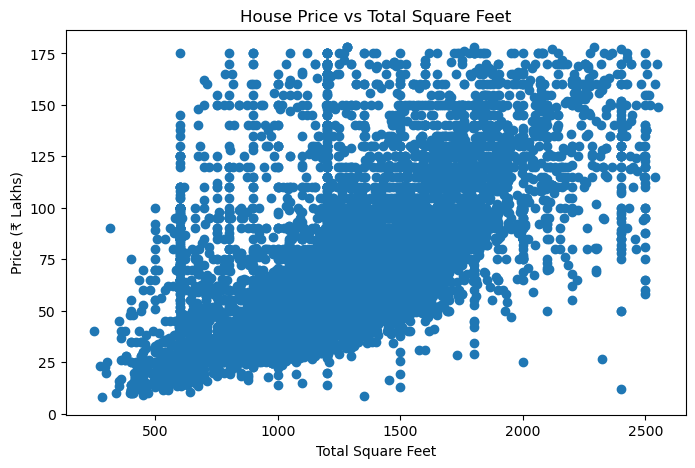

In [20]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y)

plt.xlabel("Total Square Feet")
plt.ylabel("Price (₹ Lakhs)")
plt.title("House Price vs Total Square Feet")

plt.show()

### STEP 11: Split data into training and testing sets

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)


Training data size: (8981, 1)
Testing data size: (2246, 1)


### STEP 12: Create Linear Regression model

In [22]:
model = LinearRegression()

In [23]:
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### STEP 13: Train the model

In [24]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### STEP 14: Get model coefficients

In [25]:
slope = model.coef_[0]
intercept = model.intercept_

In [26]:
print("Model slope:", slope)
print("Model intercept:", intercept)

Model slope: 0.05719247621499241
Model intercept: -1.0419275084235693


### STEP 15: Display regression equation

In [27]:
print("\nRegression Equation:")

print(
    f"Price = {intercept:.2f} + "
    f"({slope:.2f} × Total_Sqft)")


Regression Equation:
Price = -1.04 + (0.06 × Total_Sqft)


### STEP 16: Make predictions

In [28]:
y_pred = model.predict(X_test)

In [29]:
comparison = pd.DataFrame({'Actual Price': y_test.values, 'Predicted Price': y_pred})

comparison.head()


,Actual Price,Predicted Price
0,45.00,57.294398
1,130.00,110.369016
2,145.00,113.343025
3,48.00,61.869796
4,52.17,79.599464


### STEP 17: Evaluate the model

In [30]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

In [31]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 20.147832516194
MSE : 753.1955591522996
RMSE: 27.44440852254425
R²  : 0.36924767803477454


### STEP 18: Plot regression line

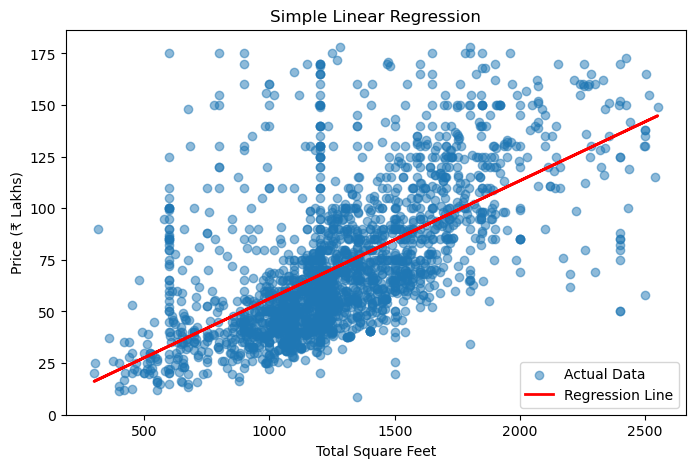

In [32]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test, y_test, alpha=0.5, label="Actual Data")

plt.plot(X_test, y_pred, linewidth=2, color = 'r', label="Regression Line")

plt.xlabel("Total Square Feet")
plt.ylabel("Price (₹ Lakhs)")
plt.title("Simple Linear Regression")
plt.legend()

plt.show()

#### STEP 19: Predict price for a new house

In [33]:
new_house = pd.DataFrame({'total_sqft': [1500]})

predicted_price = model.predict(new_house)
print(predicted_price)


[84.74678681]


In [34]:
print("Prediction for 1500 sqft house:")
predicted_sample = f"{predicted_price[0]:.2f} Lakhs"


print(predicted_sample)

Prediction for 1500 sqft house:
84.75 Lakhs


### STEP 20: Predict multiple houses 

In [35]:
new_houses = pd.DataFrame({'total_sqft': [800,1000,1200,1500,2000,2500,3000]})

predictions = model.predict(new_houses)

result = pd.DataFrame({'Total Sqft': new_houses['total_sqft'],
    'Predicted Price (Lakhs)': predictions})

print("Predictions:")
result

Predictions:


,Total Sqft,Predicted Price (Lakhs)
0,800,44.712053
1,1000,56.150549
2,1200,67.589044
3,1500,84.746787
4,2000,113.343025
5,2500,141.939263
6,3000,170.535501
